<div align="center">
  <p><strong><a href="https://br.linkedin.com/in/isaac-maciel" target="_blank">Autor do Notebook: Isaac Maciel</a></strong></p>

<p align="center">
  <img src="https://github.com/IM-NOT-AI/IM-not-AI/assets/113378671/0a6e0c0f-fcdf-4ccc-af00-63e30836d180" alt="gif_isaac_nome" width="500">
</p>

In [84]:
%reload_ext watermark
%watermark -a "Isaac Maciel" -v -m
%watermark --iversions

Author: Isaac Maciel

Python implementation: CPython
Python version       : 3.12.4
IPython version      : 9.10.0

Compiler    : MSC v.1929 64 bit (AMD64)
OS          : Windows
Release     : 11
Machine     : AMD64
Processor   : AMD64 Family 25 Model 80 Stepping 0, AuthenticAMD
CPU cores   : 16
Architecture: 64bit

json      : 2.0.9
matplotlib: 3.10.8
numpy     : 1.26.4
pandas    : 3.0.0
re        : 2.2.1



## Configuração

`[PRODUTO REAL]`

Centralizar imports e definir paths. MIMIC_ECG_ROOT aponta para os ECGs e laudos. Separar CORPUS_OUT de CHARTS_OUT mantém artefatos textuais e visuais organizados para consumo pelo NB11.

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import re
import json
import warnings
from pathlib import Path
from collections import Counter

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11

MIMIC_ECG_ROOT = Path('../../data/raw/mimic-iv-ecg/1.0')

CORPUS_OUT = Path('../../data/processed/mimic-iv-ecg/corpus')
CHARTS_OUT = Path('../../data/processed/mimic-iv-ecg/eda_charts')

CORPUS_OUT.mkdir(parents=True, exist_ok=True)
CHARTS_OUT.mkdir(parents=True, exist_ok=True)

print(f"MIMIC_ECG_ROOT: {MIMIC_ECG_ROOT.resolve()}")
print(f"CORPUS_OUT: {CORPUS_OUT.resolve()}")
print(f"CHARTS_OUT: {CHARTS_OUT.resolve()}")

MIMIC_ECG_ROOT: C:\Users\isaac\Desktop\FIAP-AI-university-projects\last_year\challenge\ai_cardiology\data\raw\mimic-iv-ecg\1.0
CORPUS_OUT: C:\Users\isaac\Desktop\FIAP-AI-university-projects\last_year\challenge\ai_cardiology\data\processed\mimic-iv-ecg\corpus
CHARTS_OUT: C:\Users\isaac\Desktop\FIAP-AI-university-projects\last_year\challenge\ai_cardiology\data\processed\mimic-iv-ecg\eda_charts


## Inventário e Escala

`[PRODUTO REAL]`

Medir a escala do dataset (800k ECGs, 19 anos de dados) contextualiza por que o corpus resultante é clinicamente representativo, um dos critérios de avaliação da banca.

In [86]:
df = pd.read_csv(MIMIC_ECG_ROOT / 'record_list.csv')
df['ecg_time'] = pd.to_datetime(df['ecg_time'])

print(f"Total de registros ECG: {len(df):,}")
print(f"Pacientes únicos: {df['subject_id'].nunique():,}")
print(f"ECGs por paciente (med): {len(df)/df['subject_id'].nunique():.1f}")
print(f"Período: {df['ecg_time'].min().date()} -> {df['ecg_time'].max().date()}")
print(f"(Datas reais: subtrair ~100 anos -> 1999-2019)")
display(df.head())

Total de registros ECG: 800,035
Pacientes únicos: 161,352
ECGs por paciente (med): 5.0
Período: 2097-08-27 -> 2211-03-27
(Datas reais: subtrair ~100 anos -> 1999-2019)


,subject_id,study_id,file_name,ecg_time,path
0,10000032,40689238,40689238,2180-07-23 08:44:00,files/p1000/p10000032/s40689238/40689238
1,10000032,44458630,44458630,2180-07-23 09:54:00,files/p1000/p10000032/s44458630/44458630
2,10000032,49036311,49036311,2180-08-06 09:07:00,files/p1000/p10000032/s49036311/49036311
3,10000117,45090959,45090959,2181-03-04 17:14:00,files/p1000/p10000117/s45090959/45090959
4,10000117,48446569,48446569,2183-09-18 13:52:00,files/p1000/p10000117/s48446569/48446569


### Distribuição Temporal de ECGs por ano 

`[PRODUTO REAL]`

Visualizar o crescimento do volume de ECGs ao longo dos 20 anos do dataset revela se há viés temporal e valida que o período (1999-2019) é consistente. A banca pode questionar por que o corpus é representativo - esta célula responde visualmente.

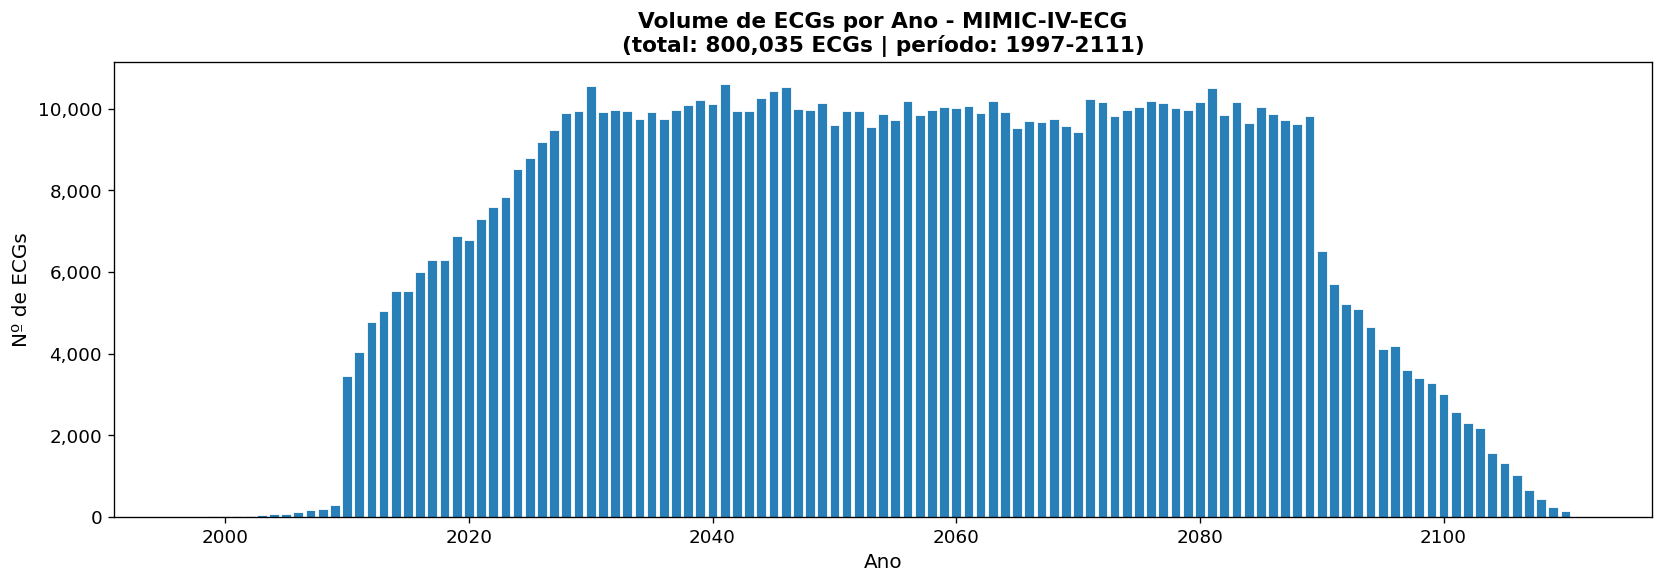

Ano com mais ECGs: 2041 (10,619)


In [87]:
df['year_real'] = df['ecg_time'].dt.year - 100  # corrige deslocamento de anonimização MIMIC

ecgs_por_ano = df['year_real'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(ecgs_por_ano.index, ecgs_por_ano.values, color='#2980b9', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Nº de ECGs', fontsize=12)
ax.set_title(
    f'Volume de ECGs por Ano - MIMIC-IV-ECG\n'
    f'(total: {len(df):,} ECGs | período: {ecgs_por_ano.index.min()}-{ecgs_por_ano.index.max()})',
    fontsize=13, fontweight='bold'
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(CHARTS_OUT / 'sec1_ecgs_por_ano.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"Ano com mais ECGs: {ecgs_por_ano.idxmax()} ({ecgs_por_ano.max():,})")

### ECGs por Paciente

A média de 5,0 ECGs/paciente não conta a história completa. A cauda da distribuição (pacientes com dezenas de ECGs) pode introduzir viés de domínio se o D3 fosse amostrado por ECG, justifica amostrar por frase única, não por ECG.

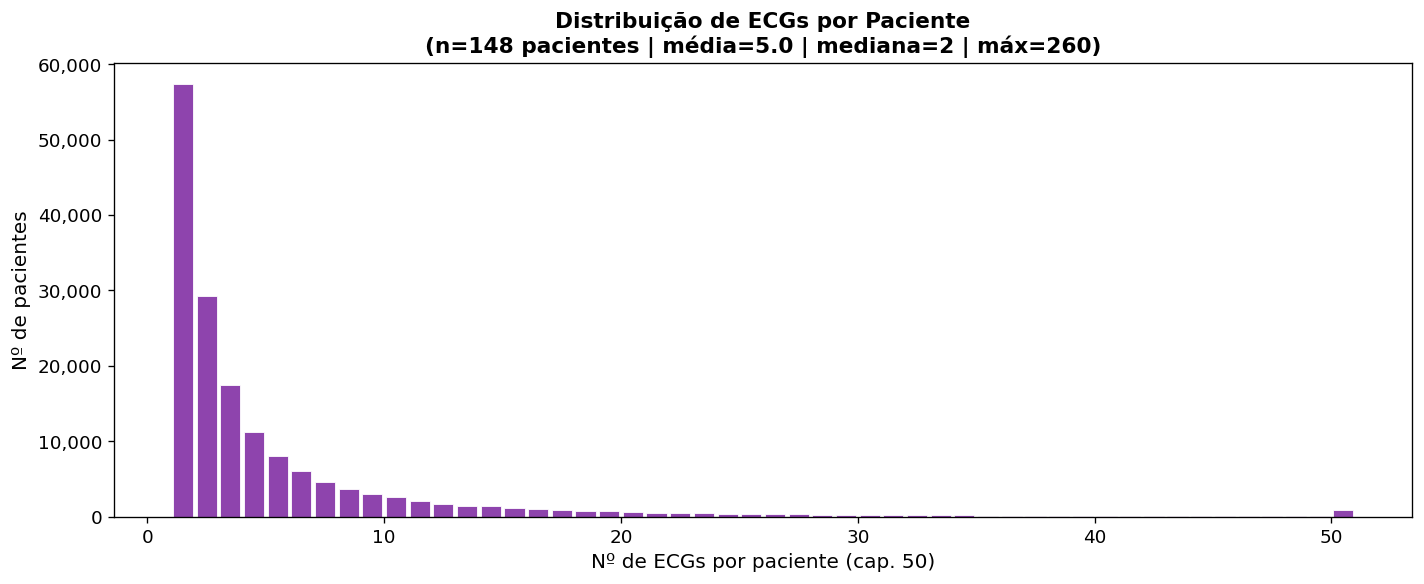

P50: 2 ECGs/paciente
P75: 5 ECGs/paciente
P90: 12 ECGs/paciente
P95: 18 ECGs/paciente
P99: 39 ECGs/paciente
Pacientes com >20 ECGs: 6,495 (4.0%)


In [88]:
ecgs_por_pac = df.groupby('subject_id').size()

fig, ax = plt.subplots(figsize=(12, 5))
cap = 50
bins = range(1, cap + 2)
ax.hist(ecgs_por_pac.clip(upper=cap), bins=bins, color='#8e44ad', edgecolor='white', linewidth=0.5, rwidth=0.85)
ax.set_xlabel(f'Nº de ECGs por paciente (cap. {cap})', fontsize=12)
ax.set_ylabel('Nº de pacientes', fontsize=12)
ax.set_title(
    f'Distribuição de ECGs por Paciente\n'
    f'(n={ecgs_por_pac.nunique():,} pacientes | média={ecgs_por_pac.mean():.1f} | '
    f'mediana={ecgs_por_pac.median():.0f} | máx={ecgs_por_pac.max()})',
    fontsize=13, fontweight='bold'
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(CHARTS_OUT / 'sec1_ecgs_por_paciente.png', bbox_inches='tight', dpi=150)
plt.show()

for p in [50, 75, 90, 95, 99]:
    print(f"P{p}: {int(np.percentile(ecgs_por_pac, p))} ECGs/paciente")
print(f"Pacientes com >20 ECGs: {(ecgs_por_pac > 20).sum():,} ({100 * (ecgs_por_pac > 20).mean():.1f}%)")

## machine_measurements: Fonte Principal do Corpus

`PRODUTO REAL`  

As 18 colunas `report_*` contêm os laudos GE MUSE em texto livre, matéria-prima do corpus. Entender a estrutura da tabela antes do flatten é essencial para não perder frases ou duplicar colunas.

In [89]:
mm = pd.read_csv(MIMIC_ECG_ROOT / 'machine_measurements.csv')

print(f"Shape: {mm.shape} ({mm.shape[0]:,} ECGs x {mm.shape[1]} colunas)")

report_cols = [c for c in mm.columns if c.startswith('report_')]
numeric_cols = [c for c in mm.columns if c not in report_cols + ['subject_id','study_id','cart_id','ecg_time']]

print(f"Colunas de texto  (report_*): {len(report_cols)}")
print(f"Colunas numéricas: {len(numeric_cols)}")

Shape: (800035, 33) (800,035 ECGs x 33 colunas)
Colunas de texto  (report_*): 18
Colunas numéricas: 11


### Taxa de Preenchimento por Coluna Report

Colunas com baixa taxa de preenchimento geram frases esparsas. Conhecer a distribuição antes do flatten ajuda a estimar o tamanho real do corpus e a detectar se alguma coluna está corrompida.


In [90]:
fill_rows = []
for col in report_cols:
    n = mm[col].notna().sum()
    fill_rows.append({'coluna': col, 'preenchidas': n, 'pct': 100*n/len(mm)})

df_fill = pd.DataFrame(fill_rows)

display(df_fill.style
    .background_gradient(subset=['pct'], cmap='YlGn')
    .format({'preenchidas': '{:,}', 'pct': '{:.1f}%'})
    .set_caption('Taxa de preenchimento das colunas report_* - MIMIC-IV-ECG')
    .hide(axis='index')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','15px'),('font-weight','bold'),('text-align','left'),('padding-bottom','6px')]},
        {'selector': 'th', 'props': [('background-color','#2c3e50'),('color','white'),('padding','8px 12px')]},
        {'selector': 'td', 'props': [('padding','6px 12px'),('border-bottom','1px solid #eee'),('font-size','14px'),('font-weight','500')]},
    ])
)

coluna,preenchidas,pct
report_0,"800,034",100.0%
report_1,"601,108",75.1%
report_2,"525,908",65.7%
report_3,"393,551",49.2%
report_4,"227,550",28.4%
report_5,"122,212",15.3%
report_6,"56,125",7.0%
report_7,"22,370",2.8%
report_8,"7,261",0.9%
report_9,"2,328",0.3%


### Exemplos Reais de Laudos

Inspeção manual confirma que as frases são laudos clínicos reais em inglês, válidos para o corpus - evita processar dados corrompidos ou em formato inesperado antes de investir no pipeline completo.

In [91]:
print("Exemplos de laudos completos (primeiros 5 ECGs com >=3 frases):\n")
sample = mm[mm[report_cols[2]].notna()].head(5)

for idx, row in sample.iterrows():
    frases = [(col, row[col]) for col in report_cols if pd.notna(row[col])]
    print(f"ECG #{idx}  (study_id: {row['study_id']}):")
    for col, frase in frases:
        print(f"{col:10s}: {frase}")
    print()

Exemplos de laudos completos (primeiros 5 ECGs com >=3 frases):

ECG #2  (study_id: 49036311):
report_0  : Sinus tachycardia
report_2  : Normal ECG except for rate

ECG #3  (study_id: 45090959):
report_0  : Sinus rhythm
report_2  : Normal ECG

ECG #6  (study_id: 41445586):
report_0  : Sinus rhythm
report_2  : Normal ECG

ECG #7  (study_id: 42695383):
report_0  : Sinus rhythm
report_1  : rSr'(V1) - probable normal variant
report_2  : Low QRS voltages in precordial leads
report_4  : Borderline ECG

ECG #8  (study_id: 40067704):
report_0  : Sinus rhythm with PAC(s).
report_2  : Borderline ECG



### Distribuição das Colunas Númericas

As 11 colunas numéricas (heart_rate, pr_interval, qt_interval, etc.) são medidas automáticas da máquina GE MUSE. Visualizar suas distribuições valida a qualidade dos dados e revela outliers clínicos - QT prolongado, bradicardia extrema - que corroboram os padrões de risco definidos na Seção 5.

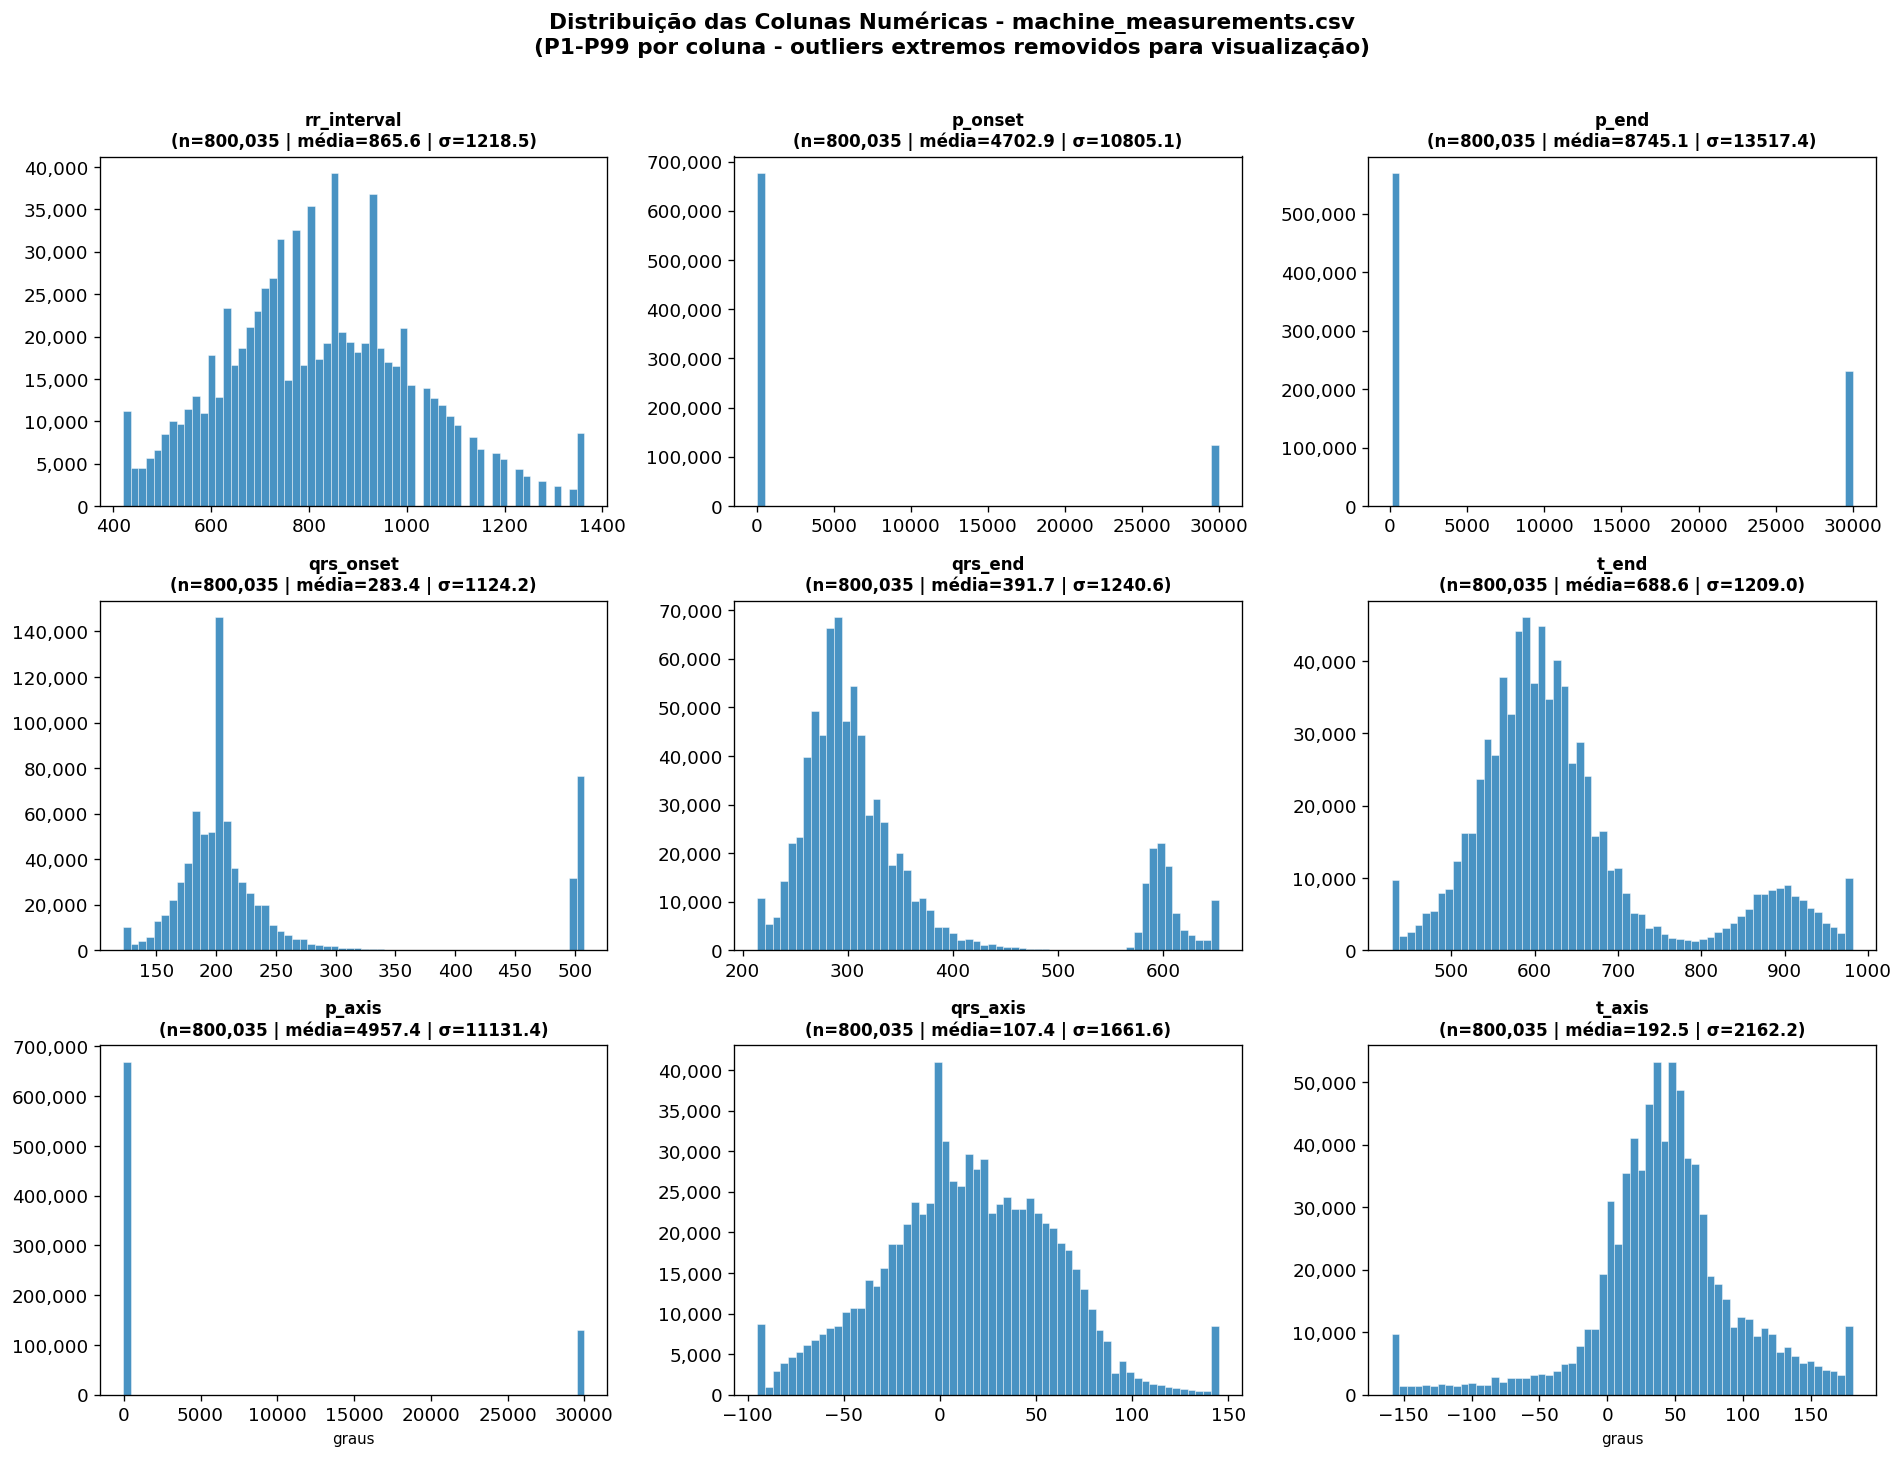

In [92]:
numeric_cols_valid = [
    c for c in numeric_cols
    if pd.api.types.is_numeric_dtype(mm[c]) and mm[c].notna().sum() > 1000
]

unidades = {
    'heart_rate': 'bpm', 'pr_interval': 'ms', 'qrs_duration': 'ms',
    'qt_interval': 'ms', 'qtc_interval': 'ms',
    'r_axis': 'graus', 't_axis': 'graus', 'p_axis': 'graus',
    'rv5': 'mV', 'sv1': 'mV', 'rv5_sv1': 'mV',
}

n_cols = len(numeric_cols_valid)
n_rows_plot = (n_cols + 2) // 3
fig, axes = plt.subplots(n_rows_plot, 3, figsize=(16, 4 * n_rows_plot))
axes = axes.flatten()

for i, col in enumerate(numeric_cols_valid):
    vals = mm[col].dropna()
    p1, p99 = vals.quantile(0.01), vals.quantile(0.99)
    vals_clip = vals.clip(p1, p99)
    unit = unidades.get(col, '')
    axes[i].hist(vals_clip, bins=60, color='#2980b9', edgecolor='white', linewidth=0.3, alpha=0.85)
    axes[i].set_title(
        f'{col}\n(n={len(vals):,} | média={vals.mean():.1f} | σ={vals.std():.1f})',
        fontsize=10, fontweight='bold'
    )
    axes[i].set_xlabel(unit, fontsize=9)
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'Distribuição das Colunas Numéricas - machine_measurements.csv\n'
    '(P1-P99 por coluna - outliers extremos removidos para visualização)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(CHARTS_OUT / 'sec2_numeric_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

## Construção e Limpeza do Corpus

### 18 Colunas → Corpus Plano

`[PRODUTO REAL]`

Flatten transforma a tabela 2D em uma série de frases para análise de frequência - pré-requisito para deduplicação e limpeza. A razão repetição/única (~884x) mostra que os laudos GE MUSE são altamente padronizados, o que beneficia o TF-IDF.

In [93]:
all_phrases = []
for col in report_cols:
    all_phrases.extend(mm[col].dropna().str.strip().str.lower().tolist())

corpus = pd.Series(all_phrases)

print(f"Total de frases (com repetições): {len(corpus):,}")
print(f"Frases únicas: {corpus.nunique():,}")
print(f"Razão repetição/única: {len(corpus)/corpus.nunique():.0f}x")

top30 = corpus.value_counts().head(30).reset_index()
top30.columns = ['frase', 'ocorrencias']
top30['pct_corpus'] = top30['ocorrencias'] / len(corpus) * 100

display(top30.style
    .background_gradient(subset=['ocorrencias'], cmap='Blues')
    .format({'ocorrencias': '{:,}', 'pct_corpus': '{:.2f}%'})
    .set_caption('Top 30 frases - corpus bruto MIMIC-IV-ECG')
    .hide(axis='index')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','15px'),('font-weight','bold'),('text-align','left'),('padding-bottom','6px')]},
        {'selector': 'th', 'props': [('background-color','#2c3e50'),('color','white'),('padding','8px 12px')]},
        {'selector': 'td', 'props': [('padding','6px 12px'),('border-bottom','1px solid #eee'),('font-size','14px'),('font-weight','500')]},
    ])
)

Total de frases (com repetições): 2,760,117
Frases únicas: 3,723
Razão repetição/única: 741x


frase,ocorrencias,pct_corpus
abnormal ecg,"355,656",12.89%
sinus rhythm,"329,165",11.93%
borderline ecg,"171,372",6.21%
normal ecg,"116,608",4.22%
left axis deviation,"75,635",2.74%
sinus rhythm.,"62,443",2.26%
sinus bradycardia,"60,874",2.21%
sinus tachycardia,"42,929",1.56%
inferior infarct - age undetermined,"41,581",1.51%
low qrs voltages in precordial leads,"40,898",1.48%


### Análise de Caracteres

`[PRODUTO REAL]` 

Mapear todos os caracteres antes de limpar evita remoção acidental de conteúdo clínico relevante. Cada categoria (letra, dígito, pontuação) recebe tratamento diferente nas etapas seguintes.

In [94]:
all_chars = Counter(''.join(corpus.tolist()))

char_rows = []
for char, count in sorted(all_chars.items(), key=lambda x: -x[1]):
    char_rows.append({
        'char': repr(char),
        'ocorrencias': count,
        'categoria': ('letra' if char.isalpha() else 'dígito' if char.isdigit() else 'espaço' if char == ' ' else 'pontuação')
    })

display(pd.DataFrame(char_rows).style
    .background_gradient(subset=['ocorrencias'], cmap='Oranges')
    .format({'ocorrencias': '{:,}'})
    .set_caption('Distribuição de Caracteres - Corpus Bruto')
    .hide(axis='index')
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color','#2c3e50'),('color','white'),('padding','8px 12px')]},
        {'selector': 'td', 'props': [('padding','6px 12px'),('border-bottom','1px solid #eee'),('font-size','14px')]},
    ])
)

char,ocorrencias,categoria
' ',"7,944,965",espaço
'e',"6,394,327",letra
'a',"6,114,562",letra
'r',"5,944,104",letra
'i',"5,016,440",letra
'n',"4,632,572",letra
't',"4,340,249",letra
's',"3,724,056",letra
'l',"3,556,486",letra
'o',"3,508,232",letra


### Investigação de Caracteres Suspeitos

`[PRODUTO REAL]`

`*, !, ?, números`, cada um pode indicar artefato de formatação ou nota de sistema GE MUSE, não laudo diagnóstico. Ver os exemplos reais decide o que remover na seção 3.4.

In [95]:
suspects = {
    '*': r'\*', '!': r'!', '?': r'\?',
    '@': r'@',  '>': r'>',  '&': r'&', 'numeros': r'\d',
}

for name, pattern in suspects.items():
    mask    = corpus.str.contains(pattern, regex=True, na=False)
    print(f"=== '{name}' — {mask.sum():,} ocorrências / {corpus[mask].nunique()} únicas ===")
    print(corpus[mask].value_counts().head(5).to_string())
    print()

=== '*' — 23,884 ocorrências / 34 únicas ===
*** consider acute st elevation mi ***                            8723
*** report made without knowing patient's sex or age ***          6998
*** report made without knowing patient's age ***                 2781
*** report made without knowing patient's sex ***                 1864
** interpretation made without knowing patient's gender/age **     426

=== '!' — 364 ocorrências / 1 únicas ===

=== '?' — 110 ocorrências / 5 únicas ===
probable sinus (? atrial) tachycardia                                          70
failure to sense and/or capture (?magnet)                                      27
probable sinus tachycardia. ? atrial tachycardia or flutter + 2:1 a-v block     7
? faulty v2 - omitted from analysis                                             5
? faulty v4 - omitted from analysis                                             1

=== '@' — 36 ocorrências / 2 únicas ===
(9@128) suggests early repolarization          35
(9@192) - canno

### Remoção de Ruído

Frases com `* report made without` e `warning data quality` são alertas do sistema GE MUSE, não diagnósticos - contaminam o corpus e distorcem o mapeamento de risco se mantidas.

In [96]:
REMOVER_PATTERNS = [
    r'^\*+\s*report made without',
    r'warning.*data quality',
]

mask_remover = corpus.str.contains('|'.join(REMOVER_PATTERNS), regex=True, na=False, flags=re.IGNORECASE)
corpus_clean = corpus[~mask_remover].copy()

print(f"Corpus original : {len(corpus):,} frases  |  {corpus.nunique():,} únicas")
print(f"Removidas       : {mask_remover.sum():,} frases  |  {corpus[mask_remover].nunique()} únicas")
print(f"Corpus limpo    : {len(corpus_clean):,} frases  |  {corpus_clean.nunique():,} únicas")
print("\nFrames únicas removidas:")
for f in sorted(set(corpus.unique()) - set(corpus_clean.unique())):
    print(f"  '{f}'")

Corpus original : 2,760,117 frases  |  3,723 únicas
Removidas       : 19,086 frases  |  5 únicas
Corpus limpo    : 2,741,031 frases  |  3,718 únicas

Frames únicas removidas:
  '*** report made without knowing patient's age ***'
  '*** report made without knowing patient's sex ***'
  '*** report made without knowing patient's sex or age ***'
  '--- warning: data quality may affect interpretation ---'
  'warning: data quality may affect computer interpretation!!'


### Normalização de Pontuação Final

`[PRODUTO REAL]`

A mesma frase com e sem ponto final são semanticamente idênticas. Colapsar reduz ruído no TF-IDF downstream e aumenta a frequência das frases únicas reais, melhorando a amostragem do D3.

In [97]:
corpus_norm = corpus_clean.str.strip().str.replace(r'[.\s]+$', '', regex=True).str.strip()

print(f"Únicas antes: {corpus_clean.nunique():,}")
print(f"Únicas após: {corpus_norm.nunique():,}")
print(f"Redução: {corpus_clean.nunique() - corpus_norm.nunique():,} frases colapsadas")

Únicas antes: 3,718
Únicas após: 3,121
Redução: 597 frases colapsadas


### Auditoria do Impacto da Normalização

Garantir que a normalização removeu apenas pontuação trailing irrelevante e não apagou conteúdo clínico - decisão auditável e rastreável para o cardiologista revisar.

In [98]:
freq_antes = corpus_clean.value_counts()
mudaram    = set(corpus_clean.unique()) - set(corpus_norm.unique())

rows = []
for f in mudaram:
    f_norm = f.strip().rstrip('. ').strip()
    rows.append({
        'frase_antes': f,
        'frase_depois': f_norm,
        'removido': repr(f[len(f_norm):]),
        'frequencia': int(freq_antes.get(f, 0)),
    })

df_norm = pd.DataFrame(rows).sort_values('frequencia', ascending=False).reset_index(drop=True)

print(f"Total alteradas: {len(df_norm):,}")
print(f"Chars removidos: {df_norm['removido'].nunique()}")
print(df_norm['removido'].value_counts().to_string())

display(df_norm.style
    .background_gradient(subset=['frequencia'], cmap='YlOrRd')
    .format({'frequencia': '{:,}'})
    .set_caption(f'Normalização - {len(df_norm):,} frases alteradas')
    .hide(axis='index')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','15px'),('font-weight','bold'),('text-align','left'),('padding-bottom','6px')]},
        {'selector': 'th', 'props': [('background-color','#2c3e50'),('color','white'),('padding','8px 12px')]},
        {'selector': 'td', 'props': [('padding','6px 12px'),('border-bottom','1px solid #eee'),('font-size','14px'),('font-weight','500')]},
    ])
)

Total alteradas: 716
Chars removidos: 1
removido
'.'    716


frase_antes,frase_depois,removido,frequencia
sinus rhythm.,sinus rhythm,'.',"62,443"
sinus tachycardia.,sinus tachycardia,'.',"13,880"
sinus bradycardia.,sinus bradycardia,'.',"11,808"
atrial fibrillation.,atrial fibrillation,'.',"8,776"
atrial fibrillation with rapid ventricular response.,atrial fibrillation with rapid ventricular response,'.',"6,058"
sinus rhythm with 1st degree a-v block.,sinus rhythm with 1st degree a-v block,'.',"3,778"
sinus rhythm with borderline 1st degree a-v block.,sinus rhythm with borderline 1st degree a-v block,'.',"3,620"
sinus arrhythmia.,sinus arrhythmia,'.',"2,580"
sinus rhythm with pac(s).,sinus rhythm with pac(s),'.',"2,534"
demand pacing.,demand pacing,'.',"2,003"


### Verificação do Merge

`[PRODUTO REAL]`

A normalização não apenas remove pontos — ela também colapsa variantes idênticas, aumentando a frequência das frases canônicas. O caso sinus rhythm é o mais impactante: sinus rhythm. (62.443 instâncias) colapsou em sinus rhythm (329.165), resultando em 391.608, a frase mais frequente do corpus final. Esta célula torna esse efeito explícito e auditável.

In [99]:
# exemplo concreto do efeito do merge pós-normalização
exemplos_merge = [
    ('sinus rhythm', 'sinus rhythm.'),
    ('sinus tachycardia', 'sinus tachycardia.'),
    ('sinus bradycardia', 'sinus bradycardia.'),
    ('atrial fibrillation', 'atrial fibrillation.'),
]

freq_bruto = corpus_clean.value_counts()
freq_apos  = corpus_norm.value_counts()

rows_merge = []
for canonica, variante in exemplos_merge:
    freq_can = int(freq_bruto.get(canonica, 0))
    freq_var = int(freq_bruto.get(variante, 0))
    freq_merged = int(freq_apos.get(canonica, 0))
    rows_merge.append({
        'frase canônica': canonica,
        'variante removida': variante,
        'freq. canônica (antes)': freq_can,
        'freq. variante (antes)': freq_var,
        'freq. após merge': freq_merged,
        'ganho': freq_merged - freq_can,
    })

display(pd.DataFrame(rows_merge).style
    .background_gradient(subset=['freq. após merge'], cmap='Blues')
    .format({c: '{:,}' for c in ['freq. canônica (antes)', 'freq. variante (antes)', 'freq. após merge', 'ganho']})
    .set_caption('Efeito do Merge Pós-Normalização - Casos mais Impactantes')
    .hide(axis='index')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','15px'),('font-weight','bold'),('text-align','left'),('padding-bottom','6px')]},
        {'selector': 'th', 'props': [('background-color','#2c3e50'),('color','white'),('padding','8px 12px')]},
        {'selector': 'td', 'props': [('padding','6px 12px'),('border-bottom','1px solid #eee'),('font-size','14px'),('font-weight','500')]},
    ])
)
print("=> 'sinus rhythm' subiu de 329.165 para 391.608 (+62.443) e se tornou a frase mais frequente do corpus.")

frase canônica,variante removida,freq. canônica (antes),freq. variante (antes),freq. após merge,ganho
sinus rhythm,sinus rhythm.,"329,165","62,443","391,608","62,443"
sinus tachycardia,sinus tachycardia.,"42,929","13,880","56,809","13,880"
sinus bradycardia,sinus bradycardia.,"60,874","11,808","72,682","11,808"
atrial fibrillation,atrial fibrillation.,"33,663","8,776","42,439","8,776"


=> 'sinus rhythm' subiu de 329.165 para 391.608 (+62.443) e se tornou a frase mais frequente do corpus.


### Limpeza Complementar

Após normalização, frases `interpretation made without knowledge...` emergem sem o prefixo `***`. São notas de sistema, removidas nesta etapa.

In [100]:
REMOVER_COMPLEMENTAR = [
    r'interpretation made without know',
    r'interpretation made without knowledge',
]

mask_comp = corpus_norm.str.contains('|'.join(REMOVER_COMPLEMENTAR), regex=True, na=False, flags=re.IGNORECASE)
corpus_final = corpus_norm[~mask_comp].copy()

print(f"corpus_norm: {corpus_norm.nunique():,} únicas")
print(f"Removidas: {corpus_norm[mask_comp].nunique()} únicas  ({mask_comp.sum():,} ocorrências)")
print(f"corpus_final: {corpus_final.nunique():,} únicas")
for f in sorted(corpus_norm[mask_comp].unique()):
    print(f"  [{int((corpus_norm == f).sum()):,}x] '{f}'")

corpus_norm: 3,121 únicas
Removidas: 6 únicas  (1,531 ocorrências)
corpus_final: 3,115 únicas
  [426x] '** interpretation made without knowing patient's gender/age **'
  [112x] '*** interpretation made without knowing patient's age ***'
  [93x] '*** interpretation made without knowing patient's gender ***'
  [100x] 'interpretation made without knowledge of patient's age'
  [388x] 'interpretation made without knowledge of patient's sex'
  [412x] 'interpretation made without knowledge of patient's sex and age'


### Funil de Redução do Corpus

Célula de fechamento da limpeza que consolida cada etapa em uma tabela única com os números reais. Responde diretamente à pergunta da banca: "quantas frases foram removidas e por quê?". Cada linha é rastreável a uma decisão de engenharia documentada acima.

In [101]:
etapas = [
    ('Flatten 18 colunas report_*', len(corpus), 'corpus bruto'),
    ('Frases únicas brutas', corpus.nunique(), 'dedup inicial'),
    ('Após remoção de ruído (3.4)', corpus_clean.nunique(), 'remove alertas GE MUSE'),
    ('Após normalização de pontuação (3.5)', corpus_norm.nunique(), 'colapsa variantes com ponto'),
    ('Após limpeza complementar (3.7)', corpus_final.nunique(), 'remove notas sem paciente'),
]

rows_funil = []
prev = None
for nome, n, motivo in etapas:
    delta = (n - prev) if prev is not None else 0
    rows_funil.append({'etapa': nome, 'frases/instâncias': n, 'delta': delta, 'motivo': motivo})
    prev = n

df_funil = pd.DataFrame(rows_funil)

display(df_funil.style
    .format({'frases/instâncias': '{:,}', 'delta': lambda v: f'{v:+,}' if v != 0 else '-'})
    .background_gradient(subset=['frases/instâncias'], cmap='YlGn')
    .set_caption('Funil de Redução do Corpus — NB9 MIMIC-IV-ECG')
    .hide(axis='index')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','15px'),('font-weight','bold'),('text-align','left'),('padding-bottom','6px')]},
        {'selector': 'th', 'props': [('background-color','#2c3e50'),('color','white'),('padding','8px 12px')]},
        {'selector': 'td', 'props': [('padding','6px 12px'),('border-bottom','1px solid #eee'),('font-size','14px'),('font-weight','500')]},
    ])
)
razao = len(corpus) / corpus_final.nunique()
print(f"Razão instâncias/frase única no corpus_final: {razao:.0f}x")
print(f"Redução total de frases únicas: {corpus.nunique()} -> {corpus_final.nunique()} ({100*(1 - corpus_final.nunique()/corpus.nunique()):.1f}% menor)")

etapa,frases/instâncias,delta,motivo
Flatten 18 colunas report_*,"2,760,117",-,corpus bruto
Frases únicas brutas,"3,723","-2,756,394",dedup inicial
Após remoção de ruído (3.4),"3,718",-5,remove alertas GE MUSE
Após normalização de pontuação (3.5),"3,121",-597,colapsa variantes com ponto
Após limpeza complementar (3.7),"3,115",-6,remove notas sem paciente


Razão instâncias/frase única no corpus_final: 886x
Redução total de frases únicas: 3723 -> 3115 (16.3% menor)


### Salvar corpus_final

`[PRODUTO REAL]`

Persistir o corpus limpo com frequência de cada frase cria uma evidência auditável do pipeline e é a entrada da Seção 5. Sem este arquivo salvo, o NB9 precisaria ser reexecutado toda vez que o NB11 fosse retreinado.

In [102]:
corpus_df_save = corpus_final.value_counts().reset_index()
corpus_df_save.columns = ['frase', 'frequencia']
corpus_df_save.to_csv(CORPUS_OUT / 'corpus_frases.csv', index=False)

print(f"Salvo: {CORPUS_OUT / 'corpus_frases.csv'}")
print(f"Shape: {corpus_df_save.shape}  ({corpus_df_save.shape[0]:,} frases únicas)")
print(f"Total instâncias: {corpus_df_save['frequencia'].sum():,}")
print(corpus_df_save.head(10).to_string(index=False))

Salvo: ..\..\data\processed\mimic-iv-ecg\corpus\corpus_frases.csv
Shape: (3115, 2)  (3,115 frases únicas)
Total instâncias: 2,739,500
                               frase  frequencia
                        sinus rhythm      391608
                        abnormal ecg      355656
                      borderline ecg      171372
                          normal ecg      116608
                 left axis deviation       75635
                   sinus bradycardia       72682
                   sinus tachycardia       56809
                 atrial fibrillation       42439
 inferior infarct - age undetermined       41581
low qrs voltages in precordial leads       40898


## Mapeamento de Risco (ACC/AHA)

### Padrões

`[PRODUTO REAL]`

Padrões ACC/AHA codificados como regex garantem rastreabilidade clínica, cada label pode ser explicado ao cardiologista. Zona cinza não entra no D3 para evitar ruído no classificador.

In [103]:
ALTO_RISCO_PATTERNS = [
    r'infarct', r'st elevation', r'consider acute', r'myocardial injur',
    r'st depression', r'ischem', r'hyperacute',
    r'\blvh\b', r'left ventricular hypertrophy',
    r'\brvh\b', r'right ventricular hypertrophy', r'biventricular hypertrophy',
    r'left bundle branch block', r'complete.*block',
    r'3rd degree', r'third degree', r'high.?grade',
    r'wolff.parkinson.white', r'\bwpw\b', r'pre.?excitation', r'delta wave',
    r'ventricular tachycardia', r'ventricular fibrillation', r'torsade',
    r'prolonged qt', r'qt prolongation',
]

BAIXO_RISCO_PATTERNS = [
    r'^normal ecg', r'^sinus rhythm$',
    r'^sinus bradycardia$', r'^sinus tachycardia$', r'^sinus arrhythmia$',
    r'probable normal variant',
    r'^left axis deviation$', r'^leftward axis$',
    r'^right axis deviation$', r'^rightward axis$',
    r'^right bundle branch block$',
    r'^sinus rhythm with pac', r'^sinus rhythm with pvc',
    r'^sinus rhythm with 1st degree', r'^sinus rhythm with borderline 1st',
    r'^sinus bradycardia with', r'^sinus tachycardia with',
    r'early repolarization', r'^junctional rhythm$',
    r'^ectopic atrial rhythm$', r'poor r.?wave progression',
]

### Classificação

 Aplicar os padrões a todas as frases únicas e registrar frequência permite amostrar as mais representativas para o D3 sem data leakage - o modelo aprende de laudos reais, não de frases artificiais.

In [104]:
frases_unicas = pd.Series(sorted(corpus_final.unique()))

def classificar_risco(frase: str):
    for pat in ALTO_RISCO_PATTERNS:
        if re.search(pat, frase, re.IGNORECASE):
            return 'alto_risco'
    for pat in BAIXO_RISCO_PATTERNS:
        if re.search(pat, frase, re.IGNORECASE):
            return 'baixo_risco'
    return None

freq_map  = corpus_final.value_counts().to_dict()
corpus_df = pd.DataFrame({
    'frase': frases_unicas,
    'risco': frases_unicas.apply(classificar_risco),
    'frequencia': frases_unicas.map(freq_map).fillna(0).astype(int),
})

n_alto = (corpus_df['risco'] == 'alto_risco').sum()
n_baixo = (corpus_df['risco'] == 'baixo_risco').sum()
n_cinza = corpus_df['risco'].isna().sum()
inst_alto = corpus_df[corpus_df['risco']=='alto_risco']['frequencia'].sum()
inst_baixo = corpus_df[corpus_df['risco']=='baixo_risco']['frequencia'].sum()
inst_cinza = corpus_df[corpus_df['risco'].isna()]['frequencia'].sum()
inst_total = corpus_df['frequencia'].sum()

print(f"alto_risco  : {n_alto:,} frases  |  {inst_alto:,} instâncias  ({100*inst_alto/inst_total:.1f}%)")
print(f"baixo_risco : {n_baixo:,} frases  |  {inst_baixo:,} instâncias  ({100*inst_baixo/inst_total:.1f}%)")
print(f"zona cinza  : {n_cinza:,} frases  |  {inst_cinza:,} instâncias  ({100*inst_cinza/inst_total:.1f}%)")

for label, cmap, cor in [('ALTO RISCO','Reds','#c0392b'),('BAIXO RISCO','Greens','#1a9850')]:
    risco_key = label.lower().replace(' ','_')
    print(f"\n=== {label} - TOP 20 ===")
    display(corpus_df[corpus_df['risco']==risco_key]
            .sort_values('frequencia', ascending=False).head(20)[['frase','frequencia']]
            .style.background_gradient(subset=['frequencia'], cmap=cmap)
            .format({'frequencia': '{:,}'})
            .hide(axis='index')
            .set_table_styles([
                {'selector': 'th', 'props': [('background-color',cor),('color','white'),('padding','8px 12px')]},
                {'selector': 'td', 'props': [('padding','6px 12px'),('font-size','14px'),('font-weight','500')]},
            ])
    )

alto_risco  : 786 frases  |  484,373 instâncias  (17.7%)
baixo_risco : 289 frases  |  1,002,676 instâncias  (36.6%)
zona cinza  : 2,040 frases  |  1,252,451 instâncias  (45.7%)

=== ALTO RISCO - TOP 20 ===


frase,frequencia
inferior infarct - age undetermined,"41,581"
prolonged qt interval,"37,540"
possible anterior infarct - age undetermined,"34,341"
left ventricular hypertrophy,"30,955"
possible inferior infarct - age undetermined,"30,680"
left bundle branch block,"23,451"
lvh with secondary repolarization abnormality,"14,791"
lateral st-t changes may be due to myocardial ischemia,"14,572"
possible anteroseptal infarct - age undetermined,"14,035"
possible left ventricular hypertrophy,"12,077"



=== BAIXO RISCO - TOP 20 ===


frase,frequencia
sinus rhythm,"391,608"
normal ecg,"116,608"
left axis deviation,"75,635"
sinus bradycardia,"72,682"
sinus tachycardia,"56,809"
poor r wave progression - probable normal variant,"37,006"
normal ecg except for rate,"36,385"
right bundle branch block,"33,837"
leftward axis,"33,662"
rsr'(v1) - probable normal variant,"17,176"


### Gráfico de Distribuição

`[PRODUTO REAL]`

Visualizar o balanço entre classes antes de gerar o D3 garante que a amostragem não criará um dataset desbalanceado - o que comprometeria a acurácia do NB11 em produção.

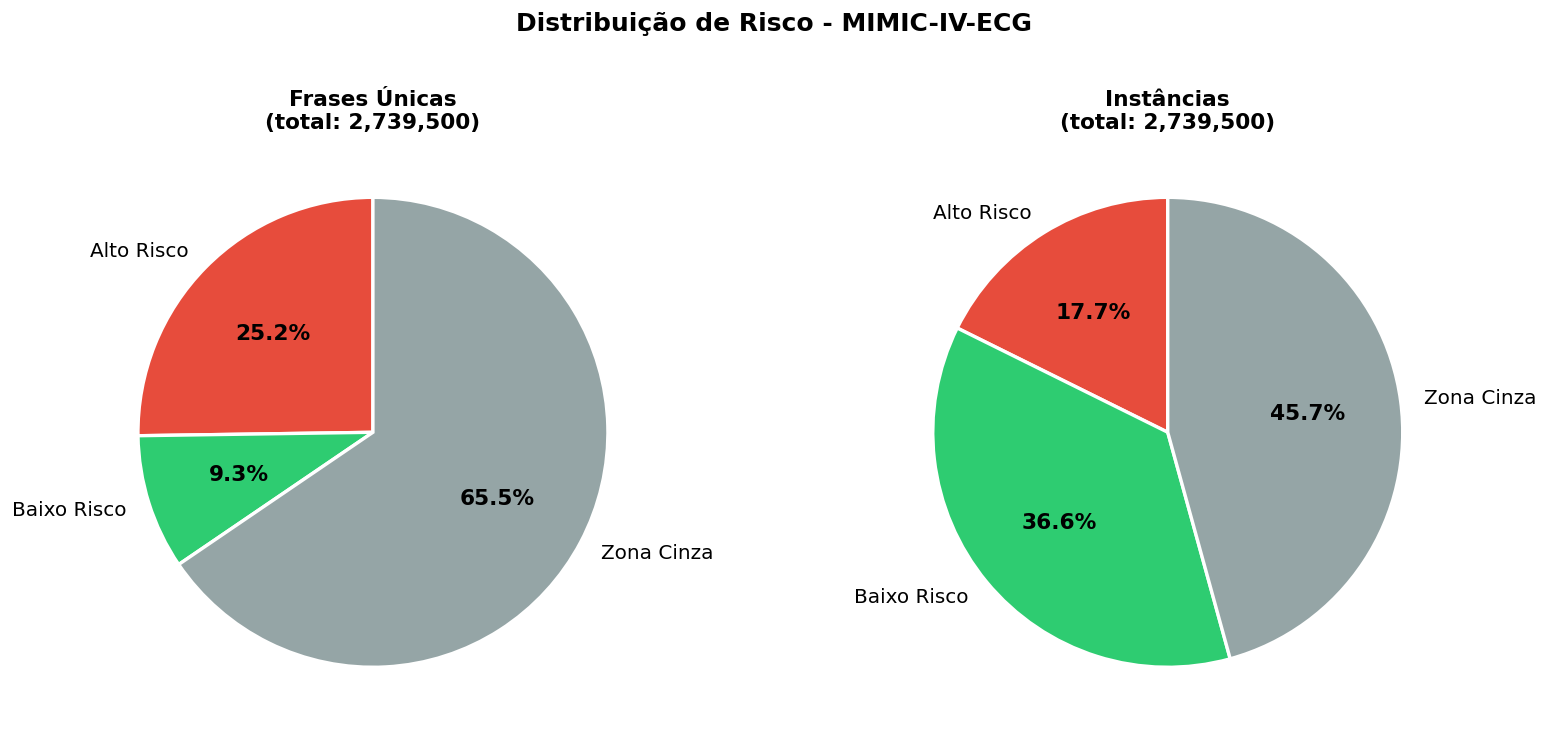

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
cores = ['#e74c3c', '#2ecc71', '#95a5a6']

for ax, vals, extra in zip(
    axes,
    [[n_alto, n_baixo, n_cinza], [inst_alto, inst_baixo, inst_cinza]],
    [f'(total: {len(corpus_df):,})', f'(total: {inst_total:,})']
):
    _, _, autotexts = ax.pie(
        vals, labels=['Alto Risco','Baixo Risco','Zona Cinza'],
        colors=cores, autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor':'white','linewidth':2}, textprops={'fontsize':12}
    )
    for at in autotexts:
        at.set_fontweight('bold')
        at.set_fontsize(13)

axes[0].set_title(f'Frases Únicas\n{extra}', fontsize=13, fontweight='bold')
axes[1].set_title(f'Instâncias\n{extra}', fontsize=13, fontweight='bold')
plt.suptitle('Distribuição de Risco - MIMIC-IV-ECG', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(CHARTS_OUT / 'sec5_distribuicao_risco.png', bbox_inches='tight', dpi=150)
plt.show()

### Análise de Zona Cinza 

`[PRODUTI REAL]`

A zona cinza (45,7% das instâncias) é a categoria mais frequente e inclui abnormal ecg - a frase mais comum do corpus inteiro com 355.656 ocorrências. Entender o que não foi classificado é tão importante quanto o que foi. Esta célula documenta por que essas frases ficaram fora do D3 e quais padrões clínicos elas representam.

Zona cinza: 2,040 frases únicas | 1,252,451 instâncias

Nota: 'abnormal ecg' (355,656 ocorrências) está na zona cinza
  -> requer interpretação cardiológica contextual, não é classificável por regex isolado.

Top 30 frases zona cinza:


frase,frequencia
abnormal ecg,"355,656"
borderline ecg,"171,372"
atrial fibrillation,"42,439"
low qrs voltages in precordial leads,"40,898"
inferior t wave changes are nonspecific,"29,560"
iv conduction defect,"25,723"
lateral t wave changes are nonspecific,"21,666"
rbbb with left anterior fascicular block,"21,027"
low qrs voltages in limb leads,"19,675"
lateral st-t changes are nonspecific,"16,878"


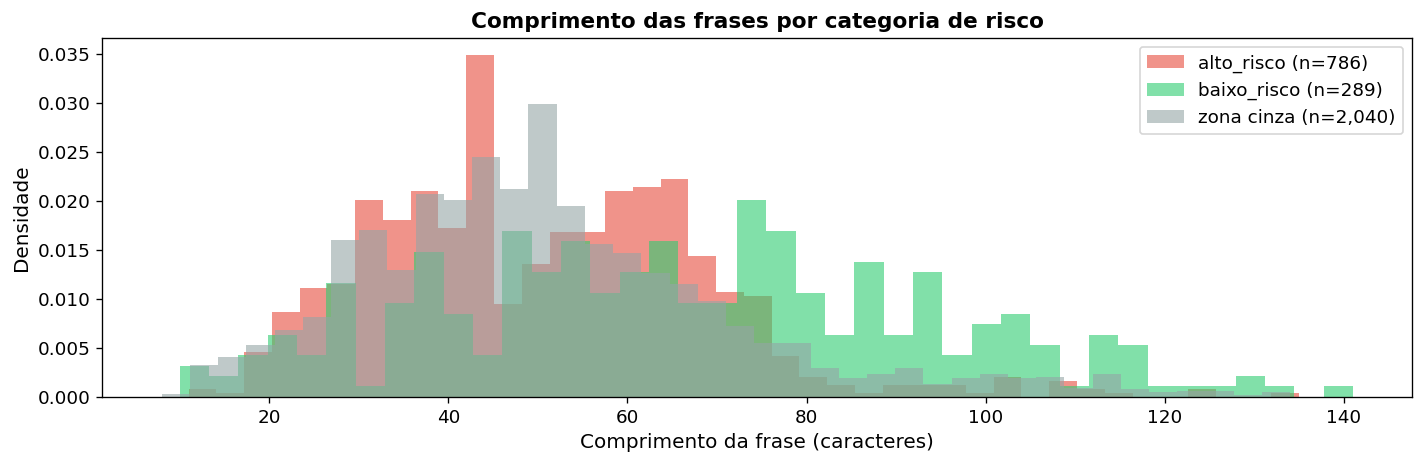

In [106]:
cinza_df = corpus_df[corpus_df['risco'].isna()].sort_values('frequencia', ascending=False).reset_index(drop=True)

print(f"Zona cinza: {len(cinza_df):,} frases únicas | {cinza_df['frequencia'].sum():,} instâncias")
print(f"\nNota: 'abnormal ecg' ({cinza_df[cinza_df['frase']=='abnormal ecg']['frequencia'].values[0]:,} ocorrências) está na zona cinza")
print("  -> requer interpretação cardiológica contextual, não é classificável por regex isolado.\n")

print("Top 30 frases zona cinza:")
display(cinza_df.head(30)[['frase', 'frequencia']].style
    .background_gradient(subset=['frequencia'], cmap='Greys')
    .format({'frequencia': '{:,}'})
    .set_caption('Top 30 frases - zona cinza (não classificadas por padrões ACC/AHA)')
    .hide(axis='index')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','15px'),('font-weight','bold'),('text-align','left'),('padding-bottom','6px')]},
        {'selector': 'th', 'props': [('background-color','#7f8c8d'),('color','white'),('padding','8px 12px')]},
        {'selector': 'td', 'props': [('padding','6px 12px'),('border-bottom','1px solid #eee'),('font-size','14px'),('font-weight','500')]},
    ])
)

# distribuição de tamanho das frases na zona cinza vs classificadas
fig, ax = plt.subplots(figsize=(12, 4))
for label, df_sub, cor in [
    ('alto_risco',  corpus_df[corpus_df['risco']=='alto_risco'],  '#e74c3c'),
    ('baixo_risco', corpus_df[corpus_df['risco']=='baixo_risco'], '#2ecc71'),
    ('zona cinza',  cinza_df, '#95a5a6'),
]:
    comprimentos = df_sub['frase'].str.len()
    ax.hist(comprimentos, bins=40, alpha=0.6, color=cor, label=f'{label} (n={len(df_sub):,})', density=True)

ax.set_xlabel('Comprimento da frase (caracteres)', fontsize=12)
ax.set_ylabel('Densidade', fontsize=12)
ax.set_title('Comprimento das frases por categoria de risco', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(CHARTS_OUT / 'sec5_zona_cinza.png', bbox_inches='tight', dpi=150)
plt.show()

## Gerar e Salvar D3

`[ENTREGAVEL + REAL]`

D3 é o dataset de entrada do NB11. 50 frases por classe garante balanceamento. Usar as mais frequentes maximiza representatividade, são os padrões que o sistema GE MUSE mais emite em ambiente hospitalar real.

In [107]:
N_POR_CLASSE = 50

d3 = pd.concat([
    corpus_df[corpus_df['risco']=='alto_risco'].sort_values('frequencia', ascending=False).head(N_POR_CLASSE),
    corpus_df[corpus_df['risco']=='baixo_risco'].sort_values('frequencia', ascending=False).head(N_POR_CLASSE),
], ignore_index=True)

D3_PATH = CORPUS_OUT / 'frases_risco_rotuladas.csv'
FULL_PATH = CORPUS_OUT / 'corpus_df_completo.csv'

d3[['frase','risco']].to_csv(D3_PATH, index=False)
corpus_df.to_csv(FULL_PATH, index=False)

print(f"D3 salvo: {D3_PATH}")
print(f"Completo: {FULL_PATH}")
print(f"D3: {d3.shape}  |  alto: {(d3['risco']=='alto_risco').sum()} | baixo: {(d3['risco']=='baixo_risco').sum()}")

display(d3.style
    .map(lambda v: 'background-color:#fde8e8;color:#c0392b;font-weight:bold'
              if v == 'alto_risco' else
              'background-color:#e8f8f0;color:#1a9850;font-weight:bold', subset=['risco'])
    .background_gradient(subset=['frequencia'], cmap='RdYlGn')
    .format({'frequencia': '{:,}'})
    .set_caption(f'D3 - {len(d3)} frases rotuladas ({N_POR_CLASSE} por classe)')
    .hide(axis='index')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','15px'),('font-weight','bold'),('text-align','left'),('padding-bottom','6px')]},
        {'selector': 'th', 'props': [('background-color','#2c3e50'),('color','white'),('padding','8px 12px')]},
        {'selector': 'td', 'props': [('padding','6px 12px'),('border-bottom','1px solid #eee'),('font-size','14px'),('font-weight','500')]},
    ])
)

D3 salvo: ..\..\data\processed\mimic-iv-ecg\corpus\frases_risco_rotuladas.csv
Completo: ..\..\data\processed\mimic-iv-ecg\corpus\corpus_df_completo.csv
D3: (100, 3)  |  alto: 50 | baixo: 50


frase,risco,frequencia
inferior infarct - age undetermined,alto_risco,"41,581"
prolonged qt interval,alto_risco,"37,540"
possible anterior infarct - age undetermined,alto_risco,"34,341"
left ventricular hypertrophy,alto_risco,"30,955"
possible inferior infarct - age undetermined,alto_risco,"30,680"
left bundle branch block,alto_risco,"23,451"
lvh with secondary repolarization abnormality,alto_risco,"14,791"
lateral st-t changes may be due to myocardial ischemia,alto_risco,"14,572"
possible anteroseptal infarct - age undetermined,alto_risco,"14,035"
possible left ventricular hypertrophy,alto_risco,"12,077"


### Resumo Executivo do Pipeline NB9

`[PRODUTO REAL]`

Célula de fechamento que consolida todos os números do pipeline em um único print, facilita a defesa verbal para a banca e serve como checkpoint antes de passar o D3 para o NB11.

In [108]:
print("=" * 60)
print("RESUMO EXECUTIVO - NB9 MIMIC-IV-ECG")
print("=" * 60)
print(f"Dataset original")
print(f"ECGs totais: {len(df):,}")
print(f"Pacientes únicos: {df['subject_id'].nunique():,}")
print(f"ECGs por paciente: {len(df)/df['subject_id'].nunique():.1f} (média)")
print(f"Período (real): 1999-2019")
print()
print(f"Pipeline de corpus")
print(f"Frases brutas: {len(corpus):,}")
print(f"Após remoção ruído: {len(corpus_clean):,}")
print(f"Após normalização: {corpus_norm.nunique():,} únicas")
print(f"corpus_final: {corpus_final.nunique():,} únicas")
print(f"Razão repetição: {len(corpus)/corpus_final.nunique():.0f}x por frase única")
print()
print(f"Mapeamento de risco (ACC/AHA)")
print(f"alto_risco: {n_alto:,} frases ({100*inst_alto/inst_total:.1f}% instâncias)")
print(f"baixo_risco: {n_baixo:,} frases ({100*inst_baixo/inst_total:.1f}% instâncias)")
print(f"zona cinza: {n_cinza:,} frases ({100*inst_cinza/inst_total:.1f}% instâncias)")
print()
print(f"D3 gerado para NB11")
print(f"Frases por classe: {N_POR_CLASSE} (balanceado)")
print(f"Total: {len(d3)}")
print(f"Path: {D3_PATH}")
print("=" * 60)

RESUMO EXECUTIVO - NB9 MIMIC-IV-ECG
Dataset original
ECGs totais: 800,035
Pacientes únicos: 161,352
ECGs por paciente: 5.0 (média)
Período (real): 1999-2019

Pipeline de corpus
Frases brutas: 2,760,117
Após remoção ruído: 2,741,031
Após normalização: 3,121 únicas
corpus_final: 3,115 únicas
Razão repetição: 886x por frase única

Mapeamento de risco (ACC/AHA)
alto_risco: 786 frases (17.7% instâncias)
baixo_risco: 289 frases (36.6% instâncias)
zona cinza: 2,040 frases (45.7% instâncias)

D3 gerado para NB11
Frases por classe: 50 (balanceado)
Total: 100
Path: ..\..\data\processed\mimic-iv-ecg\corpus\frases_risco_rotuladas.csv
